# Async Programming for AI Agents
- Notebook by Adam Lang
- Date: 8-31-2026
- This is a great review of async in Python: https://realpython.com/python-async-features/?utm_source=notification_summary&utm_medium=email&utm_campaign=2026-08-31

## Synchronous Programming

In [ ]:
import time

In [ ]:
## two independent functions synchronous

## fetch weather
def fetch_weather():
    print("Fetching weather data....")
    time.sleep(4) ## to stimulate API network delay
    print("Weather data has been fetched...")


## fetch news
def fetch_news():
    print("Fetching news data...")
    time.sleep(2) ## simulate API network delay
    print("News data has been fetched...")


### main function 
def main():
    ## start time
    start_time = time.time()

    ## use two independent functions above
    fetch_weather()
    fetch_news()

    ## end time
    end_time = time.time()
    print(f"Total time taken: {end_time - start_time} seconds")



## call main function
main()

Fetching weather data....
Weather data has been fetched...
Fetching news data...
News data has been fetched...
Total time taken: 6.004169225692749 seconds


### Summary
- We can see since it was synchronous it took more than 6 seconds.

## Async Programming

In [ ]:
import asyncio 
import time 

### Same Functions as above -- but async
- intead of `time` we use `asyncio`.

In [ ]:
## now we will make them asynchronous

## fetch weather
async def fetch_weather():
    print("Fetching weather data....")
    await asyncio.sleep(4) ## to stimulate API network delay
    print("Weather data has been fetched...")


## fetch news
async def fetch_news():
    print("Fetching news data...")
    await asyncio.sleep(2) ## simulate API network delay
    print("News data has been fetched...")


### main function 
async def main():
    ## start time
    start_time = time.time()

    ## we will instead use: asyncio.gather
    await asyncio.gather(fetch_weather(), fetch_news())


    ## end time
    end_time = time.time()
    print(f"Total time taken: {end_time - start_time} seconds")



## call main function
await main()

Fetching weather data....
Fetching news data...
News data has been fetched...
Weather data has been fetched...
Total time taken: 4.014143466949463 seconds


### Summary
- We can see it was a bit faster at 4 seconds running asynchronously. 

# Example Async with AI Agents
- Things that we can improve by doing this:
    - 1) All autonomous tasks processed automatically
    - 2) ZERO API timeouts or rate limit errors
    - 3) Application runs efficiently.  

## System Architecture
- Search tool
- Async search agent
- Summary agent


## Previous issues we often had to hardcode
-  Complex error handling
-  Rate limiting (manual setting)
-  API calls blocking

## Now we can avoid above with:
-  Automatic retry handling
-  Smart queue management
-  Non-blocking operations

## Anthropic's Parallelization concept
- Anthropic was the first to do this in 2024
- [They used parallel calls with an aggregator](https://www.anthropic.com/engineering/building-effective-agents)

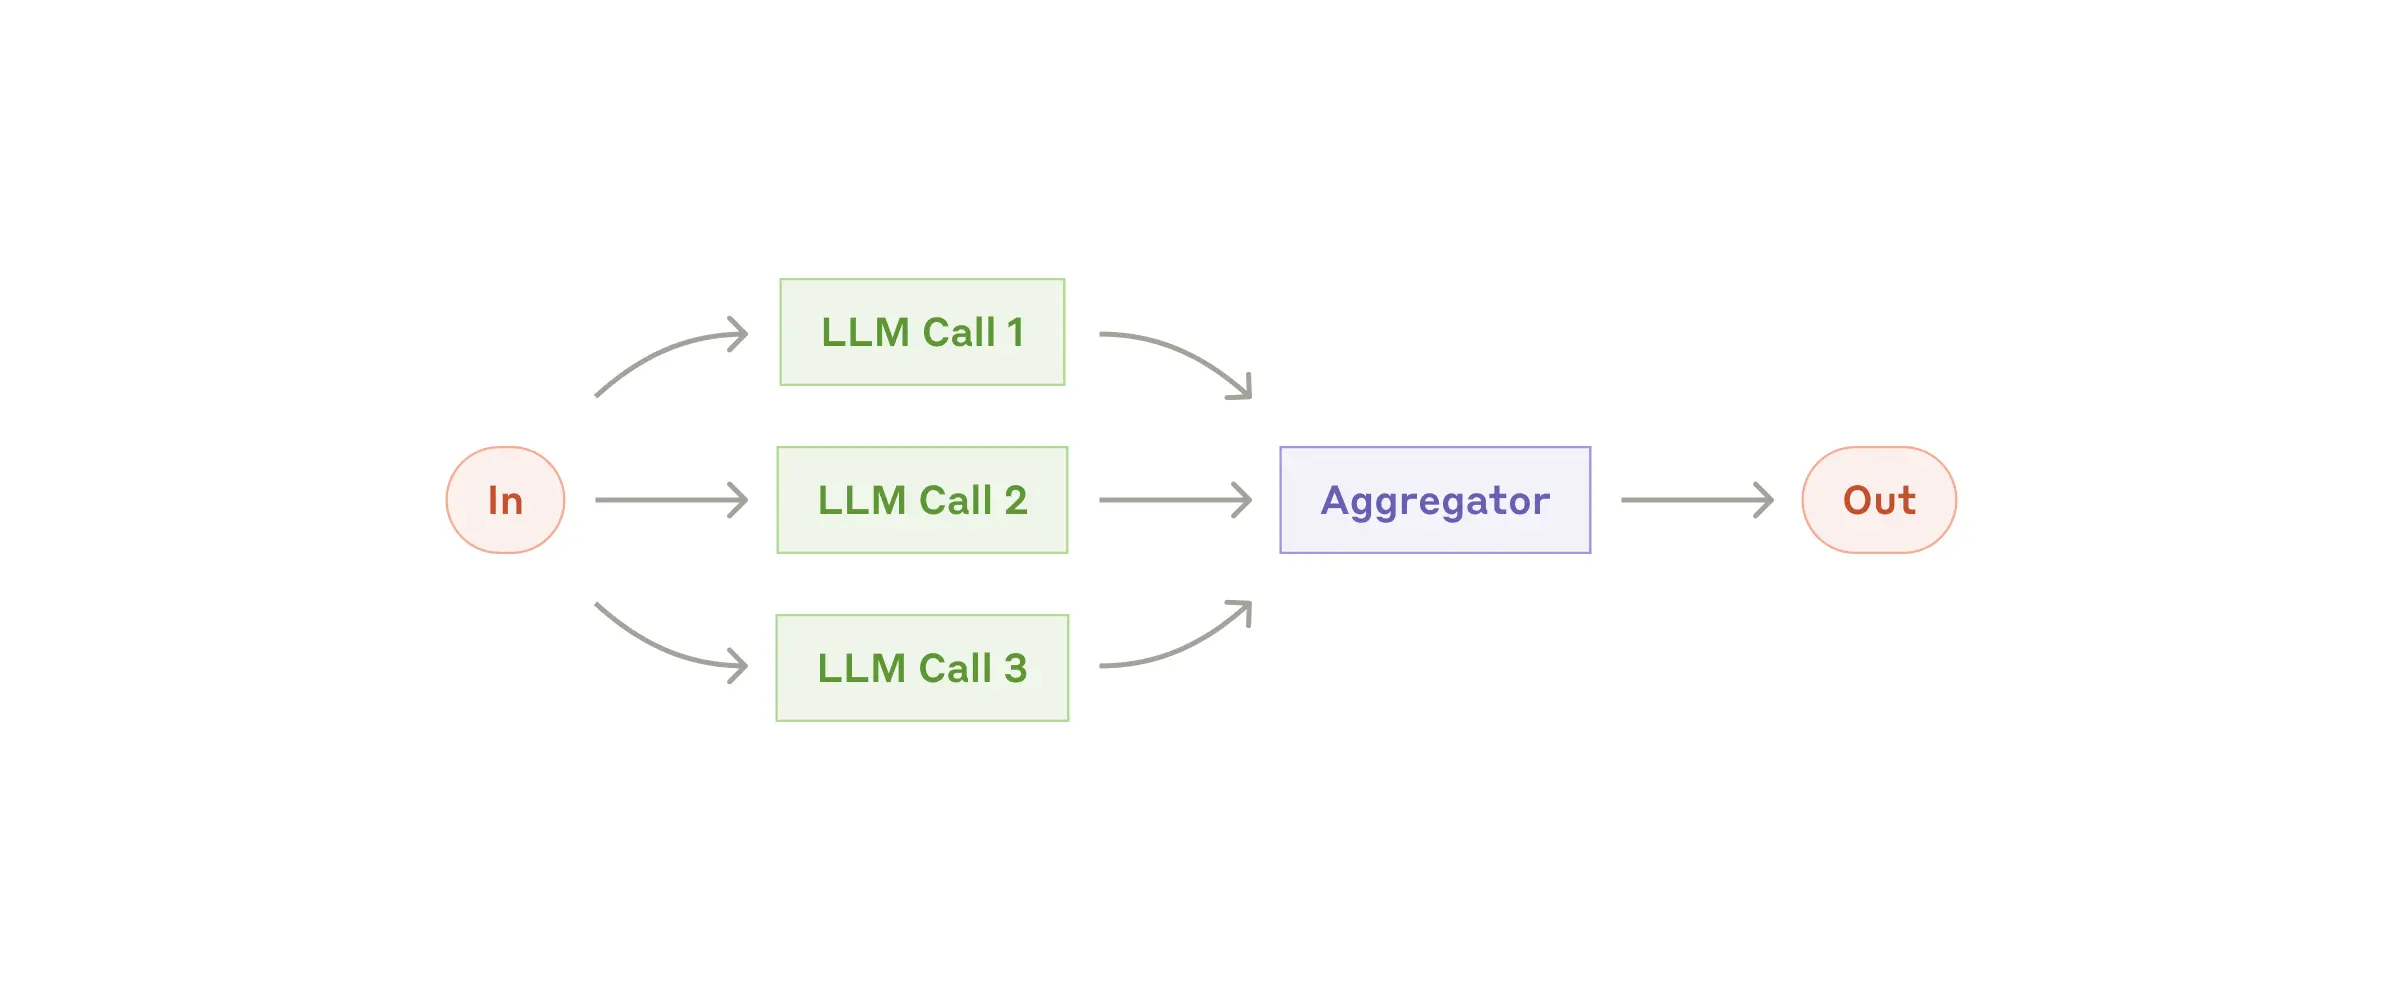

## Step 1 - install
- make sure to run in your terminal on uv: `uv pip install -U praisonai duckduckgo_search`
- using this library: https://github.com/mervinpraison/praisonai

## Step 2

In [ ]:
import asyncio
from typing import List 
from praisonaiagents import Agent, Task, PraisonAIAgents, TaskOutput
from duckduckgo_search import DDGS
from pydantic import BaseModel 